# 04. Linear Regression

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the key concepts of this topic
- Apply the topic using Python code examples
- Practice with small, realistic datasets or scenarios

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — you wrote this fit by hand there; `LinearRegression` is the same loss and the same descent, solved for you.

**Used later in:** Course 05 (AIAT 115) — Unit 4, lesson 04, which rebuilds linear regression inside a data-science workflow.

---


## 🌍 A real case: Zillow Offers, 2 November 2021

Zillow Group ran an algorithmic home-buying business: its model priced a house, Zillow bought it,
repaired it and resold it. On 2 November 2021 Zillow announced it was winding the business down. The
Q3 2021 results carried an inventory write-down of about **\$304 million** — homes bought at prices
above the company's own current estimate of what they would sell for — with a further
**\$240–265 million** of losses expected in Q4, and a reduction of roughly **25% of the workforce**.
Zillow's own statement: *"the unpredictability in forecasting home prices far exceeds what we
anticipated."*

**❗ Why this lesson exists.** A regression model always returns a number. It returns one when it is
right and it returns one when it is worse than useless — and it looks identical either way.

Watch it happen below. The simple model in Part 1 fits, plots, and reports a clean straight line —
and scores **R² = −0.0091** on the test set. A negative R² means the model is *worse than predicting
the average `Amount` for every transaction*. Its average error (MAE **\$94.67**) is larger than the
average transaction itself (\$86.92). Nothing in the fitting process warns you. R², the residual plot
and a held-out test set are the three things that do.

*(Historical note: the word "regression" comes from Galton's 1886 study of parents' and children's
heights — see the References cell. Its origin is a lesson about a line describing data, not causing it.)*


# 04. Linear Regression

---

## The Story: Finding the Best Line

Imagine you're trying to predict transaction amounts in financial investigations. **Before** using linear regression, you guess randomly or use simple averages. **After** learning linear regression, you find the best line that predicts transaction amount based on time patterns - much more accurate!

Same with machine learning: **Before** building models, we have data but no predictions. **After** linear regression, we can predict continuous values (like transaction amounts) from features (like Time, transaction patterns)!

---

## Why Linear Regression Matters

Linear regression is the foundation of machine learning:
- **Simplest ML Model**: Easy to understand and interpret
- **Fast and Efficient**: Works quickly even on large datasets
- **Interpretable**: You can see exactly how features affect predictions
- **Foundation**: Many advanced models build on linear regression concepts
- **Real-World Use**: Used in finance, healthcare, marketing, and more

---

## 🌍 Real-World Applications

**Linear Regression is used in MANY industries and situations!** Here's where you'll find it:

### 💰 Finance & Banking Sector
- **Stock Price Prediction**: Predict stock prices based on market indicators, company earnings, economic factors
- **Credit Risk Assessment**: Predict loan default risk based on income, credit history, employment status
- **Insurance Premiums**: Calculate insurance premiums based on age, health, location, coverage amount
- **Real Estate Valuation**: Predict property prices based on location, size, age, amenities
- **Sales Forecasting**: Predict future sales based on historical data, marketing spend, seasonality

### 🏥 Healthcare & Medical Sector
- **Drug Dosage Calculation**: Predict optimal drug dosage based on patient weight, age, medical history
- **Disease Progression**: Predict disease progression based on symptoms, test results, patient demographics
- **Medical Cost Prediction**: Predict treatment costs based on diagnosis, procedures, hospital stay
- **Patient Readmission Risk**: Predict likelihood of patient readmission based on medical history
- **BMI and Health Metrics**: Predict health outcomes based on lifestyle factors

### 📊 Marketing & E-commerce Sector
- **Customer Lifetime Value**: Predict how much a customer will spend over their lifetime
- **Sales Revenue Prediction**: Predict sales based on advertising spend, season, promotions
- **Price Optimization**: Predict optimal pricing based on demand, competition, costs
- **Website Traffic Prediction**: Predict website visits based on marketing campaigns, seasonality
- **Conversion Rate Prediction**: Predict purchase probability based on user behavior

### 🏭 Manufacturing & Supply Chain
- **Demand Forecasting**: Predict product demand based on historical sales, seasonality, trends
- **Quality Control**: Predict product quality based on manufacturing parameters
- **Inventory Management**: Predict optimal inventory levels based on demand patterns
- **Equipment Maintenance**: Predict maintenance needs based on usage, age, operating conditions
- **Production Cost Estimation**: Predict production costs based on materials, labor, overhead

### 🚗 Transportation & Logistics
- **Delivery Time Prediction**: Predict delivery times based on distance, traffic, weather
- **Fuel Consumption**: Predict fuel usage based on distance, vehicle type, driving conditions
- **Route Optimization**: Predict travel time for different routes
- **Fleet Management**: Predict maintenance needs based on mileage, usage patterns

### 🎓 Education Sector
- **Student Performance Prediction**: Predict grades based on attendance, study hours, previous performance
- **Admission Prediction**: Predict admission chances based on test scores, GPA, extracurriculars
- **Resource Allocation**: Predict resource needs based on enrollment, demographics

### 🏛️ Government & Public Safety Sector (Ministry of Interior)
- **Traffic Flow Prediction**: Predict traffic volume based on time, weather, events → optimize traffic management
- **Emergency Response Time**: Predict response time based on distance, traffic, time of day → optimize emergency services
- **Crime Rate Prediction**: Predict crime rates based on demographics, time, location → crime prevention planning
- **Resource Allocation**: Predict resource needs (personnel, vehicles) based on demand patterns → optimize operations
- **Traffic Accident Prediction**: Predict accident likelihood based on weather, traffic, road conditions → traffic safety
- **Border Crossing Volume**: Predict border traffic based on time, season, events → border security planning
- **Emergency Call Volume**: Predict call volume based on time, events, weather → optimize dispatch centers
- **Security Personnel Needs**: Predict staffing needs based on threat levels, events → internal organization
- **Traffic Signal Timing**: Predict optimal signal timing based on traffic patterns → reduce congestion
- **Public Safety Resource Planning**: Predict resource needs based on population, events → emergency preparedness

### 💡 Why Linear Regression is Popular in These Sectors:
- **Interpretability**: Easy to explain to non-technical stakeholders (managers, clients)
- **Fast Predictions**: Quick to train and make predictions (important for real-time systems)
- **Baseline Model**: Often used as a starting point before trying complex models
- **Regulatory Compliance**: Some industries require interpretable models (finance, healthcare)
- **Cost-Effective**: Simple to implement and maintain

### 📈 When to Use Linear Regression:
✅ **Use Linear Regression when:**
- Relationship between features and target is approximately linear
- Need interpretable model (understandable by business stakeholders)
- Working with continuous target variable (prices, quantities, scores)
- Need fast predictions on large datasets
- Want a baseline model before trying complex algorithms

❌ **Don't use Linear Regression when:**
- Relationship is highly non-linear (use polynomial regression or other models)
- Need to predict categories (use classification instead)
- Data has complex interactions between features
- Need to capture non-linear patterns

---

## Learning Objectives
1. Build simple linear regression (one feature)
2. Build multiple linear regression (multiple features)
3. Evaluate models using MSE, MAE, and R²
4. Visualize regression results and residuals
5. Understand feature importance from coefficients
6. Know when linear regression is appropriate


In [1]:
# Step 1: Import necessary libraries
import pandas as pd               # Data manipulation
import numpy as np                # Numerical operations
import matplotlib.pyplot as plt   # Visualizations
from sklearn.model_selection import train_test_split   # Splitting data
from sklearn.linear_model import LinearRegression      # The regression model!
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Libraries imported successfully!")
print("\nWhat each tool does:")
print(" - LinearRegression: builds the regression model")
print(" - train_test_split: splits data into training and test sets")
print(" - MSE / MAE / R2: metrics to evaluate model performance")

Libraries imported successfully!

What each tool does:
 - LinearRegression: builds the regression model
 - train_test_split: splits data into training and test sets
 - MSE / MAE / R2: metrics to evaluate model performance


## Setting the Scene

**BEFORE**: We have clean, preprocessed data, but we can't make predictions yet.

**AFTER**: We'll build our first ML model - linear regression - to predict continuous values (like transaction amounts) from features (like transaction time)!

**Why this matters**: Linear regression is the foundation of ML. Master this, and you understand how all ML models work!

In [2]:
print("=" * 60)
print("Example 4: Linear Regression")
print("=" * 60)

Example 4: Linear Regression


## Part 1: Simple Linear Regression

**BEFORE**: We have one feature (Time) and want to predict Amount, but we don't know the relationship.

**AFTER**: We'll find the best line (y = mx + b) that predicts Amount from Time!

**⚠️ Important Note About Expected Performance:**

You might see a low or negative R² in this section. **This is EXPECTED and INTENTIONAL!**

- We're using only ONE feature (Time) to teach the basics
- Time alone is NOT a strong predictor of Amount (this is realistic!)
- Low performance here demonstrates WHY we need multiple features
- In Part 2, we'll add more features and see BETTER performance

**This is a teaching strategy**: Simple model → See limitations → Understand why we need complexity!

**Why start with simple regression?**
- **One feature**: Easy to understand and visualize
- **Linear relationship**: Amount = slope × Time + intercept
- **Foundation**: Once you understand this, multiple regression is easy
- **Interpretable**: You can see exactly how Time affects Amount

**Why is this valuable for GDI work?**
- **Understand Basics**: Master the simplest ML model before complex ones
- **Learn ML Workflow**: See the complete process (data → model → evaluate → interpret)
- **Foundation for Fraud Detection**: Simple models help you understand what features matter
- **Build Intuition**: Seeing how one feature (Time) affects Amount helps understand patterns
- **Step to Better Models**: Once you understand simple regression, you can build more sophisticated fraud detection models

### Why Split Data into Train and Test?

**BEFORE**: We have all our data (features X and target y), but we can't use all of it for training!

**AFTER**: We'll split data into training set (80%) and test set (20%) to properly evaluate our model!

**Why split data?**

**The Problem**: If we train AND test on the same data, the model will "memorize" the data instead of learning patterns!
- **Example**: Like a student who memorizes answers to specific questions
- **Result**: Model gets perfect scores on training data, but fails on new data
- **This is called "Overfitting"** - model memorizes instead of learning

**The Solution**: Split data into TWO separate sets:
1. **Training Set (X_train, y_train)** - 80% of data
   - **Purpose**: Model LEARNS from this data
   - **What happens**: Model sees features (X_train) and correct answers (y_train)
   - **Process**: Model finds the best line that fits this data
   - **Like**: Student studying from a textbook

2. **Test Set (X_test, y_test)** - 20% of data
   - **Purpose**: Model is EVALUATED on this data
   - **What happens**: Model sees features (X_test) but NOT answers (y_test)
   - **Process**: Model makes predictions, we compare with actual answers
   - **Like**: Student taking an exam (unseen questions)

**Why this works:**
- Model learns patterns from training data (not memorizing)
- Test data is "unseen" - model hasn't seen it during training
- If model performs well on test data → model learned general patterns!
- If model performs poorly on test data → model overfitted (memorized training data)

**What are X_train, X_test, y_train, y_test?**
- **X_train**: Training features (inputs) - what model learns from
- **y_train**: Training targets (outputs) - correct answers for training
- **X_test**: Test features (inputs) - what model predicts on
- **y_test**: Test targets (outputs) - correct answers for evaluation

**Additional Notes:**

**Why 80/20 split?**
- Good balance - need enough training data (80%) to learn, enough test data (20%) to evaluate
- Can adjust: Small datasets (<1000) → 70/30, Large datasets (>10k) → 90/10

**Can I use test data for training?**
- NO! Never use test data for training - this defeats the purpose!
- Problem: If model sees test data during training, it's not a fair test
- Rule: Test data should be "locked away" until final evaluation

**What if I need more training data?**
- Use cross-validation (Unit 2) - splits data multiple ways without wasting test set

**Why split X and y separately?**
- X (features) and y (target) must stay together!
- Each row in X_train corresponds to same row in y_train
- train_test_split keeps them aligned automatically

## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: ~5,000 rows × 2 columns (transaction records × features)
  - Note: Using a sample for learning convenience (faster execution)
  - Full dataset has ~284,000 rows
- **Feature Types**: All numerical (float64) - continuous values
- **Target Type**: Regression (predicting continuous value: transaction amount)
- **Task**: Predict transaction amount (Amount) based on time elapsed (Time)
- **Data Quality**: Real anonymized credit card transaction data (perfect for learning!)

**Why This Structure Matters**:
- **Simple structure** → Easy to understand (2 columns: Time, Amount)
- **Regression task** → Predicting continuous value (Amount) from feature (Time)
- **Real-world data** → Actual anonymized credit card transaction data
- **Linear regression** → Simple model: Amount = slope × Time + intercept
- **Metrics** → We'll use regression metrics (MSE, MAE, R²)

### Understanding the Dataset Domain (Brief)

**What is this data?** Real-world financial transaction data - account balances and transaction amounts, relevant to GDI financial investigations.

**Why does this matter?** 
- **For model selection**: Predicting transaction amounts (continuous) → use regression (not classification)
- **For feature selection**: One feature (Time) → simple linear regression
- **For evaluation**: Continuous target → use regression metrics (MSE, MAE, R²)
- **For GDI work**: Understanding transaction patterns helps identify suspicious financial activities

**Domain Context** (Brief):
- **Time**: Time elapsed between transaction and first transaction (seconds) - predictor variable
- **Amount**: Transaction amount in dollars (target variable)
- **Relationship**: We're modeling how transaction amount relates to time of day/sequence
- **GDI Application**: Financial investigations analyze transaction patterns (amount vs. time) to identify suspicious activities
- **Important Note**: This is a SIMPLIFIED model for learning purposes. 
  - **Expected Performance**: Time alone is NOT a strong predictor of Amount (we'll see low/negative R²)
  - **Why simplified?**: To teach the basics of linear regression step-by-step
  - **Real GDI Work**: Uses multiple features (V1-V28, transaction history, account patterns, etc.) for accurate fraud detection
  - **Next Step**: In Part 2 (Multiple Regression), we'll add more features for better predictions!

**⚠️ Important: Why Low Performance is EXPECTED (Not a Problem!)**

You might wonder: "The R² will be very low/negative - did we choose the wrong dataset or model?"

**Answer: NO! This is INTENTIONAL and EXPECTED for learning purposes:**

1. **Why Time Alone?**
   - We use ONE feature (Time) to teach SIMPLE regression first
   - This makes it easy to visualize and understand (2D plot: Time vs Amount)
   - Simple models are easier to learn than complex ones

2. **Why Low R² is Expected:**
   - Time (seconds elapsed) doesn't strongly predict transaction Amount
   - Transaction amounts depend on MANY factors (customer behavior, merchant type, etc.)
   - One feature alone rarely captures complex patterns

3. **This is a TEACHING STRATEGY:**
   - Start simple → see limitations → extend to multiple features
   - Shows WHY we need multiple regression (Part 2)
   - Demonstrates the progression from simple to complex models

4. **Real-World Context:**
   - In real GDI work, fraud detection uses 10+ features (V1-V28, transaction patterns, etc.)
   - We'll see better performance in Part 2 when we add more features
   - This progression mirrors how ML is learned: simple → complex

**Key Takeaway**: Low R² here doesn't mean we chose wrong - it means we're learning step-by-step!

**💡 Key Point for CS Students**: You don't need to be a financial expert! Focus on:
- Understanding the **data structure** (rows, columns, types)
- Knowing the **task type** (regression: predicting continuous values)
- Choosing the right **algorithms and metrics** based on structure, not domain knowledge

In [3]:
# Load the REAL Credit Card Fraud dataset from the local datasets folder
# Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# We only need Time, V1-V3 (used in Part 2), and Amount - loading just those columns is faster
df_full = pd.read_csv('../../datasets/raw/creditcard_fraud.csv',
                      usecols=['Time', 'V1', 'V2', 'V3', 'Amount'])
print("Real-world Credit Card Fraud data loaded from local file!")
print(f" Full dataset: {len(df_full):,} transactions")

# For learning, use a 5,000-transaction sample for faster execution
df = df_full.sample(n=5000, random_state=73).reset_index(drop=True)
print(f" Using sample: {len(df):,} transactions (for faster learning)")
print(" Note: using a sample for learning convenience. In real projects, use the full dataset.")

# Part 1 uses ONE feature: predict Amount from Time
df_simple = df[['Time', 'Amount']].copy()
print("\nDataset prepared for simple linear regression!")
print(f" {len(df_simple)} transaction records")
print(" Feature: Time (seconds elapsed since the first transaction)")
print(" Target: Amount (transaction amount in dollars)")
print("\nSample data:")
print(df_simple.head().round(2))
print("\nDataset statistics:")
print(df_simple.describe().round(2))

Real-world Credit Card Fraud data loaded from local file!
 Full dataset: 284,807 transactions
 Using sample: 5,000 transactions (for faster learning)
 Note: using a sample for learning convenience. In real projects, use the full dataset.

Dataset prepared for simple linear regression!
 5000 transaction records
 Feature: Time (seconds elapsed since the first transaction)
 Target: Amount (transaction amount in dollars)

Sample data:
       Time  Amount
0   68205.0    5.49
1  168917.0   89.00
2    1051.0    0.12
3  122392.0  105.92
4  122639.0   44.90

Dataset statistics:
            Time   Amount
count    5000.00  5000.00
mean    94612.17    86.92
std     47652.92   231.02
min        33.00     0.00
25%     53967.00     6.14
50%     84505.00    21.49
75%    139520.25    74.00
max    172758.00  5239.50


In [4]:
# Prepare features (X) and target (y)
# X = what we use to predict (Time); y = what we want to predict (Amount)
X = df_simple[['Time']]
y = df_simple['Amount']
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("Feature: Time (predictor)")
print("Target: Amount (dollars)")

Features (X) shape: (5000, 1)
Target (y) shape: (5000,)
Feature: Time (predictor)
Target: Amount (dollars)


In [5]:
# Split data into training (80%) and test (20%) sets
# random_state fixes the shuffle so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=73)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 4000 samples
Test set: 1000 samples


In [6]:
# Create and train the linear regression model
# .fit() finds the best line (slope and intercept) for the training data
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
print("Model trained!")
print("The model learned the best line to predict Amount from Time")

Model trained!
The model learned the best line to predict Amount from Time


In [7]:
# Make predictions on both training and test sets
# Predicting on both lets us compare training vs test performance (overfitting check)
y_train_pred = model_simple.predict(X_train)
y_test_pred = model_simple.predict(X_test)
print("Predictions made!")
print(f" Training predictions: {len(y_train_pred)} transaction amounts")
print(f" Test predictions: {len(y_test_pred)} transaction amounts")

Predictions made!
 Training predictions: 4000 transaction amounts
 Test predictions: 1000 transaction amounts


In [8]:
# Model parameters - the learned line equation
print("Model Parameters (The Learned Line):")
print(f" Intercept (bias): ${model_simple.intercept_:,.2f}")
print(f" Coefficient (slope): {model_simple.coef_[0]:.6f} dollars per second of Time")
print(f"\n Equation: Amount = {model_simple.coef_[0]:.6f} x Time + {model_simple.intercept_:,.2f}")
direction = 'increases' if model_simple.coef_[0] > 0 else 'decreases'
print(f" Interpretation: as Time increases by 1 second, the predicted Amount")
print(f" {direction} by ${abs(model_simple.coef_[0]):.6f} - a nearly flat line")

Model Parameters (The Learned Line):
 Intercept (bias): $101.54
 Coefficient (slope): -0.000127 dollars per second of Time

 Equation: Amount = -0.000127 x Time + 101.54
 Interpretation: as Time increases by 1 second, the predicted Amount
 decreases by $0.000127 - a nearly flat line


In [9]:
# Evaluate model performance with multiple metrics
# MSE penalizes large errors; MAE is the average error in dollars; R2 is fit quality
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training Metrics (how well the model fit the training data):")
print(f" MSE: ${train_mse:,.2f} (lower is better)")
print(f" MAE: ${train_mae:,.2f} (average error in dollars)")
print(f" R2 Score: {train_r2:.4f} (closer to 1 is better)")

print("\nTest Metrics (how well the model generalizes):")
print(f" MSE: ${test_mse:,.2f}")
print(f" MAE: ${test_mae:,.2f}")
print(f" R2 Score: {test_r2:.4f}")

# Interpret R2 honestly: negative or near-zero means Time alone cannot predict Amount.
if test_r2 < 0:
    print("\n Negative R2: the model performs WORSE than always predicting the mean Amount.")
    print(" This is EXPECTED here - Time alone is not a strong predictor of Amount.")
elif test_r2 < 0.1:
    print("\n Near-zero R2: Time alone has almost no predictive power for Amount.")
    print(" This is EXPECTED for this simple one-feature model.")
else:
    print("\n R2 is higher than expected for a single weak feature.")

print("\nLearning outcome:")
print(" Simple regression (1 feature) is easy to understand, but with a weak feature")
print(" it predicts poorly - this motivates multiple regression (Part 2)!")

Training Metrics (how well the model fit the training data):
 MSE: $58,415.20 (lower is better)
 MAE: $106.16 (average error in dollars)
 R2 Score: 0.0006 (closer to 1 is better)

Test Metrics (how well the model generalizes):
 MSE: $33,146.76
 MAE: $94.67
 R2 Score: -0.0091

 Negative R2: the model performs WORSE than always predicting the mean Amount.
 This is EXPECTED here - Time alone is not a strong predictor of Amount.

Learning outcome:
 Simple regression (1 feature) is easy to understand, but with a weak feature
 it predicts poorly - this motivates multiple regression (Part 2)!


### Visualizing Simple Linear Regression

**BEFORE**: We've built the model and made predictions, but we need to see how well it fits the data!

**AFTER**: We'll create plots showing the actual data points and the regression line!

**What you'll see in the plots:**
- **Points (scatter)**: The actual data points (real Time values and transaction Amounts)
  - Blue points = Training data (what the model learned from)
  - Green points = Test data (what the model predicts on)
- **Red Line**: The regression line (model's predictions)
  - Shows how the model predicts Amount from Time
  - If points are close to the line = good predictions!
  - If points are far from the line = poor predictions

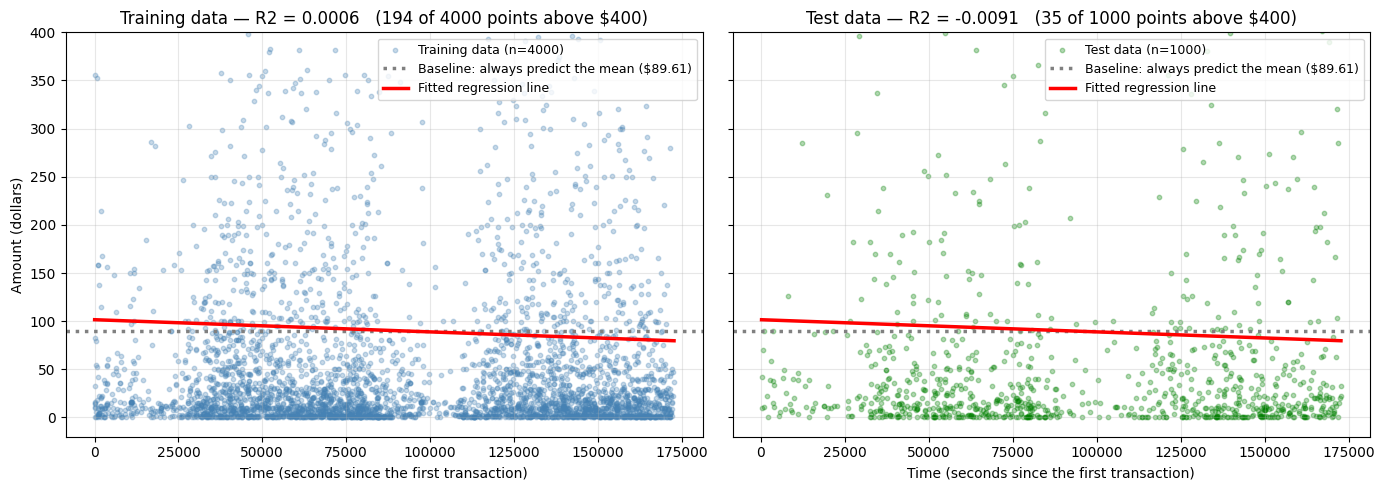

Plot saved as 'simple_linear_regression.png'
Fitted line: $101.54 at the earliest transaction (t=33s) -> $79.68 at the latest (t=172,758s).
Largest gap between the fitted line and the flat baseline: $11.93.
Baseline (mean Amount in training data): $89.61
Across two full days of Time, the fitted line moves the prediction by only $21.86.


In [10]:
# CELL: Visualise the simple regression - and put the honest baseline next to it.
# WHY: R2 = 0 has an exact meaning: "no better than always predicting the mean".
#      Drawing that mean as a second line turns the metric into something you can SEE.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

baseline = y_train.mean()          # the "always predict the average" model - R2 = 0 by definition
Y_TOP = 400                        # clip the y-axis so the dense bulk of the data is readable

panels = [
    (axes[0], X_train, y_train, y_train_pred, 'steelblue', 'Training data', train_r2),
    (axes[1], X_test, y_test, y_test_pred, 'green', 'Test data', test_r2),
]
for ax, Xp, yp, pred, colour, label, r2 in panels:
    order = np.argsort(Xp['Time'].values)
    ax.scatter(Xp, yp, alpha=0.3, s=10, color=colour, label=f'{label} (n={len(yp)})')
    # The baseline first, so the fitted line is drawn ON TOP of it and the overlap is obvious.
    ax.axhline(baseline, color='gray', linestyle=':', linewidth=2.5,
               label=f'Baseline: always predict the mean (${baseline:,.2f})')
    ax.plot(Xp['Time'].values[order], pred[order], 'r-', linewidth=2.5,
            label='Fitted regression line')
    n_above = int((yp > Y_TOP).sum())
    ax.set_xlabel('Time (seconds since the first transaction)')
    ax.set_title(f'{label} — R2 = {r2:.4f}   ({n_above} of {len(yp)} points above ${Y_TOP})')
    ax.set_ylim(-20, Y_TOP)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Amount (dollars)')

plt.tight_layout()
plt.savefig('simple_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as 'simple_linear_regression.png'")
t_lo, t_hi = X_train['Time'].min(), X_train['Time'].max()
# Evaluate the learned line y = slope*x + intercept at the two ends of the Time axis.
p_lo = model_simple.intercept_ + model_simple.coef_[0] * t_lo
p_hi = model_simple.intercept_ + model_simple.coef_[0] * t_hi
print(f"Fitted line: ${p_lo:,.2f} at the earliest transaction (t={t_lo:,.0f}s) -> "
      f"${p_hi:,.2f} at the latest (t={t_hi:,.0f}s).")
print(f"Largest gap between the fitted line and the flat baseline: "
      f"${max(abs(p_lo - baseline), abs(p_hi - baseline)):,.2f}.")
print(f"Baseline (mean Amount in training data): ${baseline:,.2f}")
print(f"Across two full days of Time, the fitted line moves the prediction by only "
      f"${y_train_pred.max() - y_train_pred.min():,.2f}.")

**Read the figure.** There are two lines in each panel, and the whole point is how little they
differ. The grey dotted line is the dumbest possible model: *ignore Time entirely and always answer
\$89.61*. The red line is what `LinearRegression().fit()` found after seeing 4,000 transactions.
They cross near the middle of the plot and are **never more than \$12 apart** anywhere on the axis:
the red line starts at \$101.54 at the earliest transaction and ends at \$79.68 at the latest — a
total travel of \$22 — while the actual amounts underneath it scatter from \$0 to over \$5,000.

That gap between the two lines is what R² measures, and here there is almost no gap:
R² = 0.0006 on training data and −0.0091 on test. **A near-zero R² is not an error in the code.
It is the picture above: the model learned nothing that "just use the average" did not already
know.** Part 2 adds V1–V3 and the picture changes.

*(The y-axis is cut at \$400 so the dense bulk of transactions is visible; the panel titles say how
many points are above the cut.)*

## Part 2: Multiple Linear Regression

**Now that we've seen simple regression with one feature, let's extend to multiple features for better predictions!**

**BEFORE**: We used one feature (Time) to predict Amount, but we saw that Time alone is NOT a strong predictor (low/negative R²). Real-world predictions need multiple features for better accuracy.

**AFTER**: We'll use multiple features (Time, V1, V2, V3) to predict Amount - this is what GDI actually uses in real financial investigations for fraud detection!

**Why multiple regression?**
- **More features = Better predictions**: Real-world financial investigations have many factors
- **Same concept**: Still finding a line, but in higher dimensions
- **Feature importance**: We can see which features matter most
- **Real-world use**: Most ML problems use multiple features

In [11]:
# Section banner: Part 2 upgrades from one feature to four (Time, V1, V2, V3).
# WHY: one weak feature gave near-zero R2 - richer features should capture more signal.
print("=" * 60)
print("Part 2: Multiple Linear Regression (Multiple Features)")
print("=" * 60)
print("\nSame workflow as simple regression, but with multiple features!")
print("We'll use Time, V1, V2, V3 to predict Amount (instead of just Time)")

Part 2: Multiple Linear Regression (Multiple Features)

Same workflow as simple regression, but with multiple features!
We'll use Time, V1, V2, V3 to predict Amount (instead of just Time)


In [12]:
# For multiple regression: use Time plus V1, V2, V3 to predict Amount
# V1-V3 are anonymized, PCA-transformed transaction features (already scaled)
df_multiple = df[['Time', 'V1', 'V2', 'V3', 'Amount']].copy()

print(f"Using {len(df_multiple):,} transaction records (same sample as Part 1)")
print(" Features: Time, V1, V2, V3 (4 features)")
print("  - Time: seconds elapsed since the first transaction")
print("  - V1, V2, V3: PCA-transformed features (already scaled, anonymized)")
print(" Target: Amount (transaction amount in dollars)")
print("\nFirst 5 rows:")
print(df_multiple.head().round(2))

Using 5,000 transaction records (same sample as Part 1)
 Features: Time, V1, V2, V3 (4 features)
  - Time: seconds elapsed since the first transaction
  - V1, V2, V3: PCA-transformed features (already scaled, anonymized)
 Target: Amount (transaction amount in dollars)

First 5 rows:
       Time    V1    V2    V3  Amount
0   68205.0 -4.41 -3.35 -2.66    5.49
1  168917.0 -0.69  0.16  0.62   89.00
2    1051.0  1.16  0.31  0.90    0.12
3  122392.0 -0.20  0.28 -1.07  105.92
4  122639.0 -0.97 -0.58 -1.19   44.90


### Preparing Features (X) and Target (y)

**BEFORE**: We have data with multiple columns, but we need to separate what we use to predict (features) from what we want to predict (target).

**AFTER**: We'll prepare X (features) and y (target) for the model!

**Why 4 features for X and 1 target for y?**

- **X (Features) = Multiple inputs** that may affect the transaction amount:
  - `Time`: Seconds elapsed since the first transaction (when the transaction happened)
  - `V1`, `V2`, `V3`: Anonymized, PCA-transformed transaction features (already scaled)
  - We use **MULTIPLE features** because transaction amount depends on **MANY factors**!

- **y (Target) = Single output** we want to predict:
  - `Amount`: The **ONE thing** we're trying to predict (transaction amount in dollars)
  - We predict **ONE value** (Amount) from **MULTIPLE inputs** (features)
  - This is the standard ML pattern: **Multiple inputs -> Single output**

**Formula:**
```
Amount = b0 + (b1 x Time) + (b2 x V1) + (b3 x V2) + (b4 x V3)
y = b0 + (b1 x x1) + (b2 x x2) + (b3 x x3) + (b4 x x4)
```

**What if I want to predict MORE than one target?**

You have **TWO options**:

1. **Build SEPARATE models** (one for each target) - **Recommended for beginners**
   - Model 1: Predict `Amount` from features
   - Model 2: Predict some other continuous target (e.g., a risk score) from features
   - **Why?** Each target might depend on the features differently
   - This is called "Multi-Output Regression" (separate models)

2. **Use Multi-Output Regression** (one model, multiple outputs)
   - `sklearn.linear_model.LinearRegression()` can handle multiple targets
   - `y` becomes a 2D array with one column per target
   - The model learns separate coefficients for each target
   - **Use when**: Targets are related and you want one model

**Recommendation**: Start with **separate models** (easier to understand and interpret). Use multi-output only if targets are strongly related.


### Splitting Data for Multiple Regression

**BEFORE**: We have features (X_multiple) and target (y_multiple), but need to split them!

**AFTER**: We'll split into training and test sets - same concept as simple regression!

**Why split?**
- **Same reason as before**: Need separate training and test sets
- **Training set**: Model learns from X_train_m and y_train_m
- **Test set**: Model is evaluated on X_test_m and y_test_m
- **Purpose**: Check if model generalizes to new data (not just memorizes)

**What we get:**
- **X_train_m**: Training features (Time, V1, V2, V3) - 80% of data
- **y_train_m**: Training targets (Amount) - 80% of data
- **X_test_m**: Test features - 20% of data
- **y_test_m**: Test targets - 20% of data

**Note**: The `_m` suffix means "multiple" (multiple features), to distinguish from simple regression variables.

In [13]:
# Prepare features (X) and target (y) for multiple regression
X_multiple = df_multiple[['Time', 'V1', 'V2', 'V3']]
y_multiple = df_multiple['Amount']

print("Features (X) and Target (y) prepared:")
print(f" Features (X) shape: {X_multiple.shape} - "
      f"{X_multiple.shape[0]} samples, {X_multiple.shape[1]} features")
print(f" - Features: {list(X_multiple.columns)}")
print(f" Target (y) shape: {y_multiple.shape} - target: Amount")
print(f"\n Ready for training: {X_multiple.shape[1]} features predict 1 target")

Features (X) and Target (y) prepared:
 Features (X) shape: (5000, 4) - 5000 samples, 4 features
 - Features: ['Time', 'V1', 'V2', 'V3']
 Target (y) shape: (5000,) - target: Amount

 Ready for training: 4 features predict 1 target


In [14]:
# Split data - same 80/20 split, same random_state for reproducibility
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=73)
print(f"Training set: {X_train_m.shape[0]} samples")
print(f"Test set: {X_test_m.shape[0]} samples")

Training set: 4000 samples
Test set: 1000 samples


In [15]:
# Create and train the multiple regression model
model_multiple = LinearRegression()
model_multiple.fit(X_train_m, y_train_m)
print("Model trained on 4 features!")

Model trained on 4 features!


In [16]:
# Predict on training and test sets
y_train_pred_m = model_multiple.predict(X_train_m)
y_test_pred_m = model_multiple.predict(X_test_m)
print(f"Predictions made: {len(y_train_pred_m)} train, {len(y_test_pred_m)} test")

Predictions made: 4000 train, 1000 test


In [17]:
# Model parameters: one coefficient per feature
print("Model Parameters:")
print(f" Intercept: {model_multiple.intercept_:.2f}")
print("\n Coefficients:")
for feature, coef in zip(X_multiple.columns, model_multiple.coef_):
    print(f"  {feature}: {coef:.4f}")

print("\n Interpretation: a larger absolute coefficient = a larger effect on the")
print(" predicted Amount. The V features share a similar scale, so their")
print(" coefficients are comparable with each other; Time is measured in seconds")
print(" (values up to ~172,000), so its small coefficient acts on a larger scale.")

Model Parameters:
 Intercept: 146.41

 Coefficients:
  Time: -0.0006
  V1: -33.6832
  V2: -79.6927
  V3: -49.1178

 Interpretation: a larger absolute coefficient = a larger effect on the
 predicted Amount. The V features share a similar scale, so their
 coefficients are comparable with each other; Time is measured in seconds
 (values up to ~172,000), so its small coefficient acts on a larger scale.


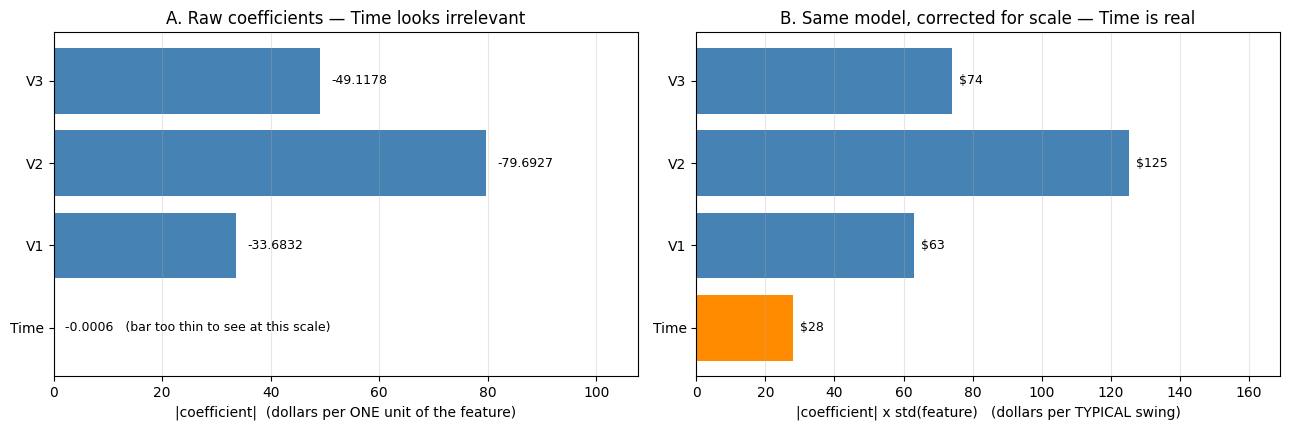

Feature     coefficient      std(feature)     effect = |coef| x std
  Time        -0.00059       47,592.993                27.92
  V1         -33.68318            1.874                63.11
  V2         -79.69269            1.570               125.13
  V3         -49.11780            1.506                73.95

Raw coefficients say V2 matters 135,838x more than Time.
Scale-corrected, V2 matters 4.5x more than Time.


In [18]:
# CELL: Turn the coefficient table above into a picture - twice, two different ways.
# WHY: read literally, the table says Time's coefficient is -0.0006 and V2's is -79.7,
#      so Time looks 130,000x less important. That reading is wrong, and the second
#      panel shows why: a coefficient is "dollars per ONE unit of the feature", and one
#      second of Time is a far smaller step than one unit of V2.
import matplotlib.pyplot as plt

feature_names = list(X_multiple.columns)
coefs = model_multiple.coef_
# Effect size = |coefficient| x (std of that feature in the TRAINING data).
# Reads as: "how many dollars the prediction moves for a typical swing in this feature".
feature_sd = X_train_m.std().values
effects = np.abs(coefs) * feature_sd

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# --- LEFT: the raw coefficients, exactly as printed above --------------------------
ax = axes[0]
ax.barh(feature_names, np.abs(coefs), color=['darkorange', 'steelblue', 'steelblue', 'steelblue'])
for i, c in enumerate(coefs):
    note = '   (bar too thin to see at this scale)' if abs(c) < 1 else ''
    ax.text(abs(c) + 2, i, f'{c:,.4f}{note}', va='center', fontsize=9)
ax.set_xlabel('|coefficient|  (dollars per ONE unit of the feature)')
ax.set_xlim(0, max(np.abs(coefs)) * 1.35)
ax.set_title('A. Raw coefficients — Time looks irrelevant')
ax.grid(axis='x', alpha=0.3)

# --- RIGHT: the same model, scaled by how much each feature actually varies ---------
ax = axes[1]
ax.barh(feature_names, effects, color=['darkorange', 'steelblue', 'steelblue', 'steelblue'])
for i, e in enumerate(effects):
    ax.text(e + 2, i, f'${e:,.0f}', va='center', fontsize=9)
ax.set_xlabel('|coefficient| x std(feature)   (dollars per TYPICAL swing)')
ax.set_xlim(0, effects.max() * 1.35)
ax.set_title('B. Same model, corrected for scale — Time is real')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Feature     coefficient      std(feature)     effect = |coef| x std")
for n, c, s, e in zip(feature_names, coefs, feature_sd, effects):
    print(f"  {n:5s} {c:14,.5f} {s:16,.3f} {e:20,.2f}")
print(f"\nRaw coefficients say V2 matters {abs(coefs[2] / coefs[0]):,.0f}x more than Time.")
print(f"Scale-corrected, V2 matters {effects[2] / effects[0]:.1f}x more than Time.")

**Read the figure.** Both panels describe the *same fitted model* — no refitting, no new data.

*Panel A* is the coefficient table drawn as bars. `Time`'s bar (orange) is invisible next to
`V2`'s: 0.0006 against 79.7, a ratio of about 135,000. A student reading only this panel concludes
"drop Time, it does nothing".

*Panel B* multiplies each coefficient by the standard deviation of its own feature, which converts
"dollars per one unit" into "dollars per typical swing in this column". Now `Time` moves the
prediction by about **\$28** across a normal day-to-day swing, against \$63 for V1, \$125 for V2
and \$74 for V3. `Time` is the *weakest* of the four — but by a factor of about 4, not 135,000.

The lesson: **a coefficient is only comparable to another coefficient when the two features share
a unit.** `V1`–`V3` came out of a PCA and share one; `Time` is in seconds and does not. This is the
same scale problem Example 3 raised, arriving here as a wrong conclusion about which feature
matters — and it is exactly why Example 6 standardises before it compares Ridge and Lasso
coefficients.

In [19]:
# Evaluate the multiple regression model
train_mse_m = mean_squared_error(y_train_m, y_train_pred_m)
test_mse_m = mean_squared_error(y_test_m, y_test_pred_m)
test_mae_m = mean_absolute_error(y_test_m, y_test_pred_m)
train_r2_m = r2_score(y_train_m, y_train_pred_m)
test_r2_m = r2_score(y_test_m, y_test_pred_m)

print("Training Metrics:")
print(f" MSE: {train_mse_m:,.2f}")
print(f" RMSE: {np.sqrt(train_mse_m):,.2f}")
print(f" R2 Score: {train_r2_m:.4f}")

print("\nTest Metrics:")
print(f" MSE: {test_mse_m:,.2f}")
print(f" RMSE: {np.sqrt(test_mse_m):,.2f}")
print(f" MAE: {test_mae_m:,.2f}")
print(f" R2 Score: {test_r2_m:.4f}")

# Head-to-head comparison: did adding V1-V3 actually beat the Time-only baseline?
print("\n" + "=" * 60)
print("Comparing Simple vs Multiple Regression (test R2)")
print("=" * 60)
print(f" Simple (Time only): {test_r2:.4f}")
print(f" Multiple (Time + V1 + V2 + V3): {test_r2_m:.4f}")
if test_r2_m > test_r2:
    print(" Multiple regression performs better - more features capture more patterns!")
else:
    print(" Multiple regression did NOT beat simple regression on this split.")

if test_r2_m >= 0.9:
    print(f"\n EXCELLENT fit: R2 = {test_r2_m:.2f} (>90% of variance explained)")
elif test_r2_m >= 0.7:
    print(f"\n GOOD fit: R2 = {test_r2_m:.2f} (>70% of variance explained)")
elif test_r2_m >= 0.5:
    print(f"\n FAIR fit: R2 = {test_r2_m:.2f} (>50% of variance explained)")
else:
    print(f"\n Still a MODEST fit: R2 = {test_r2_m:.2f} (<0.5) - these 4 features")
    print(" explain only part of Amount's variance. Real fraud models use many")
    print(" more features (V1-V28, transaction history, merchant data, ...).")

gap = abs(train_r2_m - test_r2_m)
if gap < 0.05:
    print(f"\n Train R2 ({train_r2_m:.4f}) and test R2 ({test_r2_m:.4f}) are similar")
    print(" - good generalization, no strong overfitting.")
else:
    print(f"\n Train R2 ({train_r2_m:.4f}) vs test R2 ({test_r2_m:.4f}): a gap of")
    print(f" {gap:.4f}. A moderate gap like this is worth watching for overfitting.")

Training Metrics:
 MSE: 38,510.24
 RMSE: 196.24
 R2 Score: 0.3412

Test Metrics:
 MSE: 23,693.51
 RMSE: 153.93
 MAE: 79.13
 R2 Score: 0.2787

Comparing Simple vs Multiple Regression (test R2)
 Simple (Time only): -0.0091
 Multiple (Time + V1 + V2 + V3): 0.2787
 Multiple regression performs better - more features capture more patterns!

 Still a MODEST fit: R2 = 0.28 (<0.5) - these 4 features
 explain only part of Amount's variance. Real fraud models use many
 more features (V1-V28, transaction history, merchant data, ...).

 Train R2 (0.3412) vs test R2 (0.2787): a gap of
 0.0625. A moderate gap like this is worth watching for overfitting.


### Visualizing Multiple Linear Regression

**BEFORE**: We've built a multiple regression model, but how do we visualize it with multiple features?

**AFTER**: We'll plot predicted vs actual transaction amounts to see how well the model performs!

**What you'll see in the plots:**
- **Points (scatter)**: Each point = one transaction
  - X-axis: Actual Amount (what the transaction actually was)
  - Y-axis: Predicted Amount (what the model predicted)
  - If points are close to the diagonal line = good predictions!
  - If points are far from the diagonal line = poor predictions
- **Red Dashed Line**: Perfect prediction line (y = x)
  - If predictions were perfect, all points would be on this line
  - Points above line = model over-predicted (predicted higher than actual)
  - Points below line = model under-predicted (predicted lower than actual)

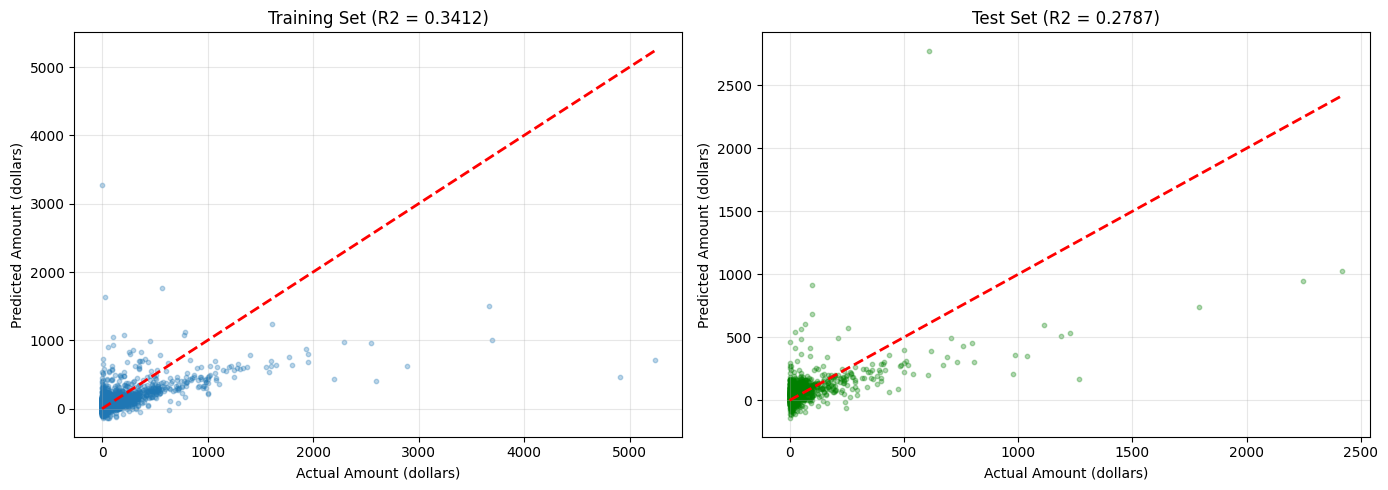

Plot saved as 'multiple_linear_regression.png'
Points near the red diagonal = good predictions. Most points sit below
the diagonal's upper range: the model struggles with very large amounts.


In [20]:
# Visualize multiple regression: predicted vs actual (diagonal = perfect prediction)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: training set - each dot compares an actual amount with its prediction.
axes[0].scatter(y_train_m, y_train_pred_m, alpha=0.3, s=10)
axes[0].plot([y_train_m.min(), y_train_m.max()], [y_train_m.min(), y_train_m.max()],
             'r--', linewidth=2)
axes[0].set_xlabel('Actual Amount (dollars)')
axes[0].set_ylabel('Predicted Amount (dollars)')
axes[0].set_title(f'Training Set (R2 = {train_r2_m:.4f})')
axes[0].grid(True, alpha=0.3)

# Right: test set - if the model generalizes, this cloud should look like the left one.
axes[1].scatter(y_test_m, y_test_pred_m, alpha=0.3, s=10, color='green')
axes[1].plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
             'r--', linewidth=2)
axes[1].set_xlabel('Actual Amount (dollars)')
axes[1].set_ylabel('Predicted Amount (dollars)')
axes[1].set_title(f'Test Set (R2 = {test_r2_m:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multiple_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'multiple_linear_regression.png'")
print("Points near the red diagonal = good predictions. Most points sit below")
print("the diagonal's upper range: the model struggles with very large amounts.")

## 💬 Discuss

1. **Simple regression: R² = −0.0091. Multiple regression: R² = 0.2787.** A negative R² means the
   model loses to a constant. Would you rather ship a model with R² = −0.01, or no model at all?
   Be concrete: in a system that *must* output a number for every transaction, what does "no model"
   actually deploy?

2. **Adding V1, V2 and V3 moved test R² from −0.01 to 0.28.** Suppose three more features move it to
   0.31. Is that worth collecting them? State the threshold you would use — and say whether it is a
   threshold in R², in money, or in something else entirely.

3. **The coefficients are Time −0.0006, V1 −33.68, V2 −79.69, V3 −49.12.** A manager reads that as
   "V2 matters a hundred thousand times more than Time." Is the manager right? What would you have to
   do to the data before that comparison is fair — and, once you have done it, what would *still* be
   wrong with reading coefficients as importance?


## Part 3: Understanding Residuals

**Now that we've built and evaluated our models, let's learn about residuals - a powerful diagnostic tool!**

### What Are Residuals?

**BEFORE**: We've evaluated our model with metrics (MSE, MAE, R²), but there's another important way to check model quality!

**AFTER**: We'll learn what residuals are and why they're important for diagnosing model problems!

**What are Residuals? (Simple Explanation)**

**Residuals = Prediction Errors = The Mistake the Model Made**

Think of it like this:
- You take a **test** (actual exam)
- You **predict** what score you'll get
- The **residual** = How wrong your prediction was!

**In Machine Learning:**
- **Actual Value** = What really happened (real transaction amount)
- **Predicted Value** = What the model guessed (predicted transaction amount)
- **Residual** = The difference (how wrong the model was)

**Formula:**
```
Residual = Actual Value - Predicted Value
         = y_actual - y_predicted
```

**Real-World Example (GDI Financial Investigation Context):**

Imagine predicting transaction amounts:
- **Transaction 1**: 
  - Actual amount: $30,000
  - Model predicted: $28,000
  - **Residual**: $30,000 - $28,000 = **+$2,000**
  - Meaning: Model **under-predicted** by $2,000 (predicted too low)

- **Transaction 2**:
  - Actual amount: $25,000
  - Model predicted: $27,000
  - **Residual**: $25,000 - $27,000 = **-$2,000**
  - Meaning: Model **over-predicted** by $2,000 (predicted too high)

- **Transaction 3**:
  - Actual amount: $20,000
  - Model predicted: $20,000
  - **Residual**: $20,000 - $20,000 = **$0**
  - Meaning: **Perfect prediction!** No error!

**Key Points:**
- **Positive residual** = Model predicted **too low** (actual > predicted)
- **Negative residual** = Model predicted **too high** (actual < predicted)
- **Residual = 0** = **Perfect prediction!**
- **Small residual** = Good prediction ✅
- **Large residual** = Bad prediction ❌

**Why Check Residuals? (Why This Matters)**

1. **See Individual Mistakes**: 
   - MSE/MAE/R² give us **average** performance
   - Residuals show us **each individual** prediction error
   - Example: "Transaction 1 was off by $2k, Transaction 2 was perfect, Transaction 3 was off by $0.5k"

2. **Find Patterns**:
   - If residuals are **random** = Good model ✅
   - If residuals show **patterns** (curves, trends) = Model has problems ❌
   - Patterns tell us **what's wrong** with the model

3. **Diagnose Problems**:
   - **Curved pattern** = Model can't capture non-linear relationships
   - **Funnel shape** = Model errors get bigger for certain values
   - **Outliers** = Some predictions are way off (need to check data)

**What's the Difference Between Residuals and Other Metrics?**

| Aspect | Residuals | MSE/MAE/R² |
|--------|-----------|------------|
| **What they show** | **Individual errors** for each prediction | **Average/summary** of all errors |
| **Example** | Transaction 1: -$0.5k, Transaction 2: +$2k, Transaction 3: $0 | Average error: $1k |
| **Use for** | **Diagnosing problems** (find patterns) | **Overall performance** (how good is model?) |
| **Shows patterns?** | ✅ YES - can see curves, funnels, trends | ❌ NO - just one number |
| **Shows outliers?** | ✅ YES - can see which predictions are way off | ❌ NO - outliers averaged out |
| **Interpretation** | "This transaction was off by $2k" | "Average error is $1k" |

**Real Example (GDI Financial Investigation Context):**

Imagine you predicted transaction amounts for 3 transactions:
- **Transaction 1**: Actual $30k, Predicted $29.5k → Residual = +$0.5k
- **Transaction 2**: Actual $25k, Predicted $27k → Residual = -$2k  
- **Transaction 3**: Actual $20k, Predicted $20k → Residual = $0

**Metrics tell you:**
- **MSE**: Average squared error = (0.5² + 2² + 0²)/3 = 1.42
- **MAE**: Average absolute error = (0.5 + 2 + 0)/3 = $0.83k
- **R²**: How well model fits = 0.85 (85% variance explained)

**Residuals tell you:**
- Transaction 1: Small error ($0.5k) ✅
- Transaction 2: Larger error ($2k) ❌ - **Why?** Need to investigate! (Could indicate suspicious pattern)
- Transaction 3: Perfect ($0) ✅

**Key Difference:**
- **Metrics (MSE/MAE/R²)**: Give you **one number** summarizing all predictions
- **Residuals**: Give you **individual errors** for each prediction

**Why Both Matter:**
- **Use Metrics**: To answer "Is my model good overall?" (R² = 0.85 → good!)
- **Use Residuals**: To answer "Which predictions are wrong and why?" (Transaction 2 is way off → check data!)
- **Together**: Metrics show overall quality, residuals show where problems are!

**Additional Notes:**

**What does "residual" mean in simple words?**
- **"Residual" = leftover error** = what the model got wrong
- Like: You predict you'll get 90% on a test, but you actually got 85%
- Residual = 85% - 90% = -5% (you over-predicted by 5%)
- It's the "leftover" mistake after the model makes its prediction

**Why check residuals if we already have MSE/MAE/R²?**
- Metrics give us **numbers** (average performance)
- Residuals show us **patterns** (what's wrong)
- Example: MSE might be low, but residuals show a curve → model has problems
- Residuals help diagnose **WHAT'S wrong**, not just **HOW wrong**

**Should residuals be positive or negative?**
- **Both!** Good models have residuals randomly scattered around 0
- Some predictions too high (negative), some too low (positive)
- Mean of residuals should be close to 0 (no systematic bias)
- If all residuals are positive → model always predicts too low
- If all residuals are negative → model always predicts too high

**What's the difference between residuals and errors?**
- They're **the same thing!** 
- "Residual" = technical term used in statistics
- "Error" = more general term
- Both mean: difference between actual and predicted

**How do I know if residuals are good or bad?**
- Good residuals:
  - **Mean close to 0** (no bias)
  - **Small spread** (consistent predictions)
  - **Random pattern** (no curves or trends)
- Bad residuals:
  - **Mean far from 0** (systematic bias)
  - **Large spread** (inconsistent predictions)
  - **Patterns** (curves, funnels, trends)

### Calculating Residuals

**Now that we understand what residuals are, let's calculate them for our multiple regression model!**

**BEFORE**: We know what residuals are, now let's calculate them!

**AFTER**: We'll compute residuals and check their statistics to see if our model is good!

**What we'll calculate:**
- **Residuals**: `residuals = y_test - y_test_pred`
  - For each test sample: actual transaction amount - predicted transaction amount
  - Positive = model under-predicted, Negative = model over-predicted
- **Statistics**: Mean, standard deviation, min, max
  - Mean close to 0 = no bias ✅
  - Small std = consistent predictions ✅

In [21]:
# Calculate residuals (prediction errors) for the multiple regression model
# Residual = actual - predicted (positive = under-predicted, negative = over-predicted)
residuals = y_test_m - y_test_pred_m

print(f"Residuals calculated: {len(residuals)} residuals")
print(f" Mean residual: ${residuals.mean():.2f} (should be close to 0)")
print(f" Std residual: ${residuals.std():.2f}")
print(f" Min: ${residuals.min():.2f} | Max: ${residuals.max():.2f}")

# Rule of thumb: |mean| above ~10% of the std suggests systematic bias
bias_threshold = residuals.std() * 0.1
if abs(residuals.mean()) > bias_threshold:
    direction = 'UNDER-predicts' if residuals.mean() > 0 else 'OVER-predicts'
    print(f"\n Systematic bias detected: the model {direction} by")
    print(f" ${abs(residuals.mean()):.2f} on average")
else:
    print(f"\n No significant systematic bias: |mean| = ${abs(residuals.mean()):.2f}")
    print(f" is below 10% of the residual std (${bias_threshold:.2f})")

Residuals calculated: 1000 residuals
 Mean residual: $-8.35 (should be close to 0)
 Std residual: $153.78
 Min: $-2165.60 | Max: $1396.22

 No significant systematic bias: |mean| = $8.35
 is below 10% of the residual std ($15.38)


### Visualizing Residuals

**BEFORE**: We've calculated residual statistics, but we need to visualize them to see patterns!

**AFTER**: We'll create plots to check if residuals are randomly distributed (good) or have patterns (indicates problems)!

**Why visualize residuals?**
- **Check assumptions**: Linear regression assumes residuals are random and normally distributed
- **Detect patterns**: Patterns in residuals indicate model problems (non-linearity, heteroscedasticity)
- **Diagnose issues**: Visual inspection helps identify what's wrong with the model
- **Validate model**: Good models have randomly scattered residuals around zero

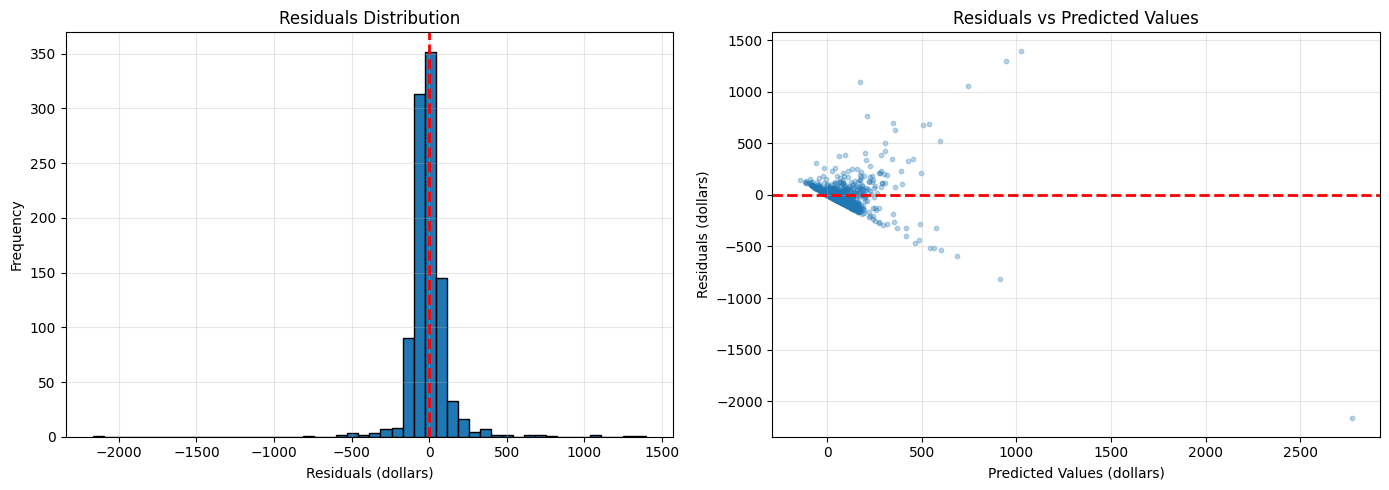

Plot saved as 'residuals_analysis.png'
The histogram is centered near 0 but has long tails: a few transactions
are missed by hundreds of dollars even though the average error is small.


In [22]:
# Visualize residuals: distribution + residuals vs predicted values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of errors - centered on 0 means no systematic over/under-prediction.
axes[0].hist(residuals, bins=50, edgecolor='black')
axes[0].axvline(0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuals (dollars)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Residuals Distribution')
axes[0].grid(True, alpha=0.3)

# Right: errors vs predictions - a visible funnel or curve would mean missed structure.
axes[1].scatter(y_test_pred_m, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values (dollars)')
axes[1].set_ylabel('Residuals (dollars)')
axes[1].set_title('Residuals vs Predicted Values')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'residuals_analysis.png'")
print("The histogram is centered near 0 but has long tails: a few transactions")
print("are missed by hundreds of dollars even though the average error is small.")

## Part 4: Fixing Prediction Bias

**Sometimes models have systematic bias - let's learn how to identify and address it!**

### What to Do When Predictions Are Too Low (or Too High)

**BEFORE**: You've analyzed residuals and found that your model systematically under-predicts (or over-predicts). Now what?

**AFTER**: You'll learn practical solutions to fix systematic bias in your predictions!

**What We Found in OUR Run (see the residual statistics printed above):**
- **Residual Mean**: about -$8 on the test set, versus a residual std of about $154
- **Interpretation**: Our model shows **no large systematic bias** - the mean error is small relative to the spread of errors
- **Meaning**: On average the predictions are only a few dollars off-center; individual errors can still be large (that is what the std measures)

**Why This Matters:**
- **Systematic bias** = Model consistently makes the same type of error
- **Good models** should have residual mean close to 0 (no bias)
- **Biased models** = Poor predictions, even if R² is high

---

### 🔍 Diagnose the Problem

**Check Your Residuals:**

1. **Residual Mean**:
   - **Close to 0** (±small value) → ✅ No bias, model is good
   - **Positive mean** → ⚠️ Model UNDER-predicts (predictions too low)
   - **Negative mean** → ⚠️ Model OVER-predicts (predictions too high)

2. **Residual Patterns**:
   - **Random scatter** → ✅ Good (no patterns)
   - **Curved pattern** → ⚠️ Non-linear relationship (need polynomial regression)
   - **Funnel shape** → ⚠️ Heteroscedasticity (variance changes with predictions)

3. **Residual Distribution**:
   - **Normal distribution** → ✅ Good (assumption met)
   - **Skewed distribution** → ⚠️ Model bias or outliers

**In Our Case:**
- Mean residual (about -$8) is well under 10% of the residual std (about $154) → no significant bias
- We still demonstrate each solution below, so you can apply them when bias IS present in your own models

---

### 🛠️ Solutions to Fix Systematic Bias

#### Solution 1: Check for Missing Features

**Problem**: Model might be missing important features that affect the target.

**Example:**
- Predicting house price from size only
- But price also depends on location, age, condition
- Missing features → Model can't capture full relationship → Under-predicts

**What to Do:**
1. **Review your data**: Are there other features that affect the target?
2. **Add relevant features**: Include features that logically affect predictions
3. **Check feature importance**: Use domain knowledge to identify missing factors

---

**Code Example (see cell below for executable version):**
- Before: Only using Time
- After: Using multiple relevant features (Time, V1, V2, V3, V4, etc.)

---

#### Solution 2: Check for Data Quality Issues

**Problem**: Data issues can cause bias:
- **Outliers**: Extreme values skew the model
- **Missing values**: Incorrectly handled missing data
- **Data leakage**: Using future information
- **Wrong target values**: Incorrect labels in training data

**What to Do:**
1. **Check for outliers**: Plot data, look for extreme values
2. **Handle missing values**: Impute or remove missing data properly
3. **Verify target values**: Make sure y values are correct
4. **Check data distribution**: Ensure training and test data are similar

**Code Example:**
```python
# Check for outliers
import matplotlib.pyplot as plt
plt.boxplot(y_train)
plt.title('Check for Outliers in Target')
plt.show()

# Remove outliers (if appropriate)
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
outliers = (y_train < (Q1 - 1.5 * IQR)) | (y_train > (Q3 + 1.5 * IQR))
X_train_clean = X_train[~outliers]
y_train_clean = y_train[~outliers]
```

---

#### Solution 3: Try Feature Engineering

**Problem**: Raw features might not capture relationships well.

**What to Do:**
1. **Create interaction features**: Multiply features together (e.g., size × bedrooms)
2. **Transform features**: Log, square, or other transformations
3. **Create polynomial features**: Add squared or cubed terms
4. **Normalize/scale features**: Ensure all features are on similar scales

**Code Example:**
```python
# Create interaction features
df_multiple['Time_V1'] = df_multiple['Time'] * df_multiple['V1']
df_multiple['Time_V2'] = df_multiple['Time'] * df_multiple['V2']

# Transform features (if needed, e.g. for skewed features)
df_multiple['log_Time'] = np.log1p(df_multiple['Time'])

# Use new features
X = df_multiple[['Time', 'V1', 'V2', 'V3', 'Time_V1', 'Time_V2']]
```

---

#### Solution 4: Try Different Models

**Problem**: Linear regression might not be appropriate for your data.

**What to Do:**
1. **Polynomial Regression**: If relationship is curved (non-linear)
2. **Ridge/Lasso Regression**: If you have many features (regularization)
3. **Random Forest**: If relationship is complex and non-linear
4. **XGBoost**: For best performance on complex patterns

**Code Example:**
```python
# Try Polynomial Regression (for non-linear relationships)
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)
model_poly = LinearRegression()
model_poly.fit(X_poly, y_train)
```

---

#### Solution 5: Adjust the Intercept (Last Resort)

**Problem**: Model intercept might be systematically wrong.

**What to Do:**
1. **Calculate mean residual**: This is the systematic bias
2. **Adjust predictions**: Add mean residual to all predictions
3. **Note**: This is a "band-aid" solution - better to fix the root cause!

**Code Example:**
```python
# Calculate mean residual (systematic bias)
mean_residual = residuals.mean()
print(f"Systematic bias: {mean_residual:.2f}")

# Adjust predictions
y_test_pred_adjusted = y_test_pred + mean_residual

# Recalculate metrics
mse_adjusted = mean_squared_error(y_test, y_test_pred_adjusted)
print(f"Original MSE: {test_mse:.2f}")
print(f"Adjusted MSE: {mse_adjusted:.2f}")
```

**⚠️ Warning**: This doesn't fix the model - it just shifts predictions. Better to fix the root cause!

---

### 📊 Decision Tree: Which Solution to Try?

**Start Here:**

1. **Check residual mean**:
   - If close to 0 → ✅ Model is good, no action needed
   - If far from 0 → Continue to step 2

2. **Check residual patterns**:
   - **Curved pattern** → Try Solution 4 (Polynomial Regression)
   - **Random scatter** → Continue to step 3

3. **Check your features**:
   - **Few features (<5)** → Try Solution 1 (Add more features)
   - **Many features (>10)** → Try Solution 3 (Feature engineering)

4. **Check data quality**:
   - **Outliers present** → Try Solution 2 (Fix data quality)
   - **No outliers** → Continue to step 5

5. **Try different models**:
   - **Linear relationship** → Current model should work (check features)
   - **Non-linear relationship** → Try Solution 4 (Different models)

6. **Last resort**:
   - If nothing works → Try Solution 5 (Adjust intercept)
   - But remember: This is a band-aid, not a real fix!

---

### ✅ Key Takeaways

1. **Residual mean ≠ 0** = Systematic bias (model consistently wrong)
2. **Positive mean** = Under-prediction (predictions too low)
3. **Negative mean** = Over-prediction (predictions too high)
4. **Fix root cause** = Better than adjusting predictions
5. **Check features first** = Most common cause of bias
6. **Try different models** = If linear regression isn't appropriate

---

### 🎯 Next Steps

**After fixing bias:**
1. **Re-train model** with improved features/data
2. **Re-evaluate** residuals (should be close to 0 now)
3. **Check metrics** (MSE, MAE, R² should improve)
4. **Validate** on new data to ensure fix works

**If bias persists:**
- Consider that linear regression might not be appropriate
- Try polynomial regression or other non-linear models
- Consult domain experts about missing features

In [23]:
# Solution 1 Example: Adding More Features
print("=" * 60)
print("Solution 1: Adding More Features")
print("=" * 60)

print("\nBefore (Simple Regression - Time only):")
print(f" Test R2: {test_r2:.4f} (essentially no predictive power)")

print("\nAfter (Multiple Regression - Time + V1 + V2 + V3):")
print(f" Test R2: {test_r2_m:.4f} (better - more features capture more patterns)")

print("\nTo add even more features from this dataset:")
print(" X_extended = df_full[['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']]")
print(" More relevant features usually help - but watch for overfitting!")

Solution 1: Adding More Features

Before (Simple Regression - Time only):
 Test R2: -0.0091 (essentially no predictive power)

After (Multiple Regression - Time + V1 + V2 + V3):
 Test R2: 0.2787 (better - more features capture more patterns)

To add even more features from this dataset:
 X_extended = df_full[['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']]
 More relevant features usually help - but watch for overfitting!


Solution 2: Checking for Data Quality Issues (Outliers)

Checking for outliers in the target variable (Amount):
 Mean Amount: $86.92
 Median Amount: $21.49
 Std Amount: $231.02
 Q1: $6.13 | Q3: $74.00 | IQR: $67.86
 Lower bound: $-95.66 | Upper bound: $175.80

 IQR outliers: 577 (11.5%)


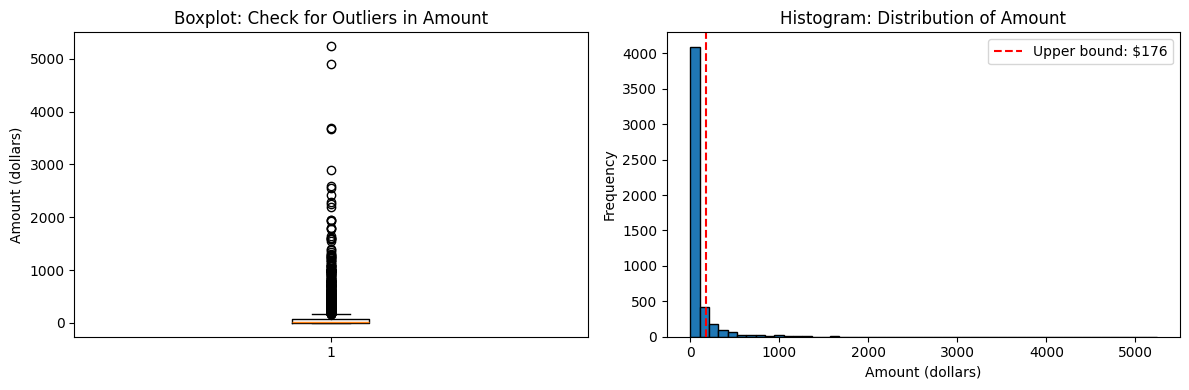


Note: transaction amounts are heavily right-skewed, so the IQR rule
flags many high-value transactions. In this dataset those are mostly
LEGITIMATE large payments - only remove outliers if they are data errors!


In [24]:
# Solution 2 Example: Checking for Outliers in the Target Variable
print("=" * 60)
print("Solution 2: Checking for Data Quality Issues (Outliers)")
print("=" * 60)

print("\nChecking for outliers in the target variable (Amount):")
print(f" Mean Amount: ${y_multiple.mean():.2f}")
print(f" Median Amount: ${y_multiple.median():.2f}")
print(f" Std Amount: ${y_multiple.std():.2f}")

# IQR rule: flag values beyond 1.5*IQR outside the quartiles as potential outliers.
Q1 = y_multiple.quantile(0.25)
Q3 = y_multiple.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f" Q1: ${Q1:.2f} | Q3: ${Q3:.2f} | IQR: ${IQR:.2f}")
print(f" Lower bound: ${lower_bound:.2f} | Upper bound: ${upper_bound:.2f}")

outliers = (y_multiple < lower_bound) | (y_multiple > upper_bound)
num_outliers = outliers.sum()
print(f"\n IQR outliers: {num_outliers} ({num_outliers / len(y_multiple) * 100:.1f}%)")

# Visual check: the boxplot and histogram make the skew and flagged region visible.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.boxplot(y_multiple)
plt.title('Boxplot: Check for Outliers in Amount')
plt.ylabel('Amount (dollars)')
plt.subplot(1, 2, 2)
plt.hist(y_multiple, bins=50, edgecolor='black')
plt.axvline(upper_bound, color='r', linestyle='--',
            label=f'Upper bound: ${upper_bound:.0f}')
plt.title('Histogram: Distribution of Amount')
plt.xlabel('Amount (dollars)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print("\nNote: transaction amounts are heavily right-skewed, so the IQR rule")
print("flags many high-value transactions. In this dataset those are mostly")
print("LEGITIMATE large payments - only remove outliers if they are data errors!")

In [25]:
# Solution 3 Example: Feature Engineering
print("=" * 60)
print("Solution 3: Feature Engineering (Creating New Features)")
print("=" * 60)

print("\nCreating interaction features:")
df_multiple_demo = df_multiple.copy()
df_multiple_demo['Time_V1'] = df_multiple_demo['Time'] * df_multiple_demo['V1']
df_multiple_demo['Time_V2'] = df_multiple_demo['Time'] * df_multiple_demo['V2']
print(" Created: Time x V1 interaction")
print(" Created: Time x V2 interaction")
print(" Interaction features can capture combined effects that single features miss")

print("\nTransforming features (check skewness first):")
time_skew = df_multiple_demo['Time'].skew()
print(f" Time skewness: {time_skew:.2f}")
if abs(time_skew) > 1:
    df_multiple_demo['log_Time'] = np.log1p(df_multiple_demo['Time'])
    print(" Time is skewed - created log(Time + 1)")
else:
    print(" Time is not heavily skewed - transformation not necessary")

print("\nTo use engineered features:")
print(" X_engineered = df_multiple_demo[['Time', 'V1', 'V2', 'V3', 'Time_V1', 'Time_V2']]")
print(" then train the model with X_engineered instead of X_multiple")

Solution 3: Feature Engineering (Creating New Features)

Creating interaction features:
 Created: Time x V1 interaction
 Created: Time x V2 interaction
 Interaction features can capture combined effects that single features miss

Transforming features (check skewness first):
 Time skewness: -0.03
 Time is not heavily skewed - transformation not necessary

To use engineered features:
 X_engineered = df_multiple_demo[['Time', 'V1', 'V2', 'V3', 'Time_V1', 'Time_V2']]
 then train the model with X_engineered instead of X_multiple


In [26]:
# Solution 4 Example: Trying Different Models (Polynomial Regression preview)
from sklearn.preprocessing import PolynomialFeatures

print("=" * 60)
print("Solution 4: Trying Different Models (Polynomial Regression)")
print("=" * 60)

print("\nCurrent model: Linear Regression (assumes straight-line relationships)")
print("Alternative: Polynomial Regression (handles curved relationships by")
print("creating polynomial features: x, x^2, and feature interactions)")

# Quick demonstration on a small sample
X_sample_poly = X_train_m[:100]
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_demo = poly.fit_transform(X_sample_poly)

print(f"\n Original features shape: {X_sample_poly.shape}")
print(f" Polynomial features shape: {X_poly_demo.shape}")
print(f" Degree-2 polynomial expansion turns {X_sample_poly.shape[1]} features")
print(f" into {X_poly_demo.shape[1]} (originals + squares + pairwise interactions)")

print("\nPolynomial Regression is covered in detail in: 05_polynomial_regression.ipynb")

Solution 4: Trying Different Models (Polynomial Regression)

Current model: Linear Regression (assumes straight-line relationships)
Alternative: Polynomial Regression (handles curved relationships by
creating polynomial features: x, x^2, and feature interactions)

 Original features shape: (100, 4)
 Polynomial features shape: (100, 14)
 Degree-2 polynomial expansion turns 4 features
 into 14 (originals + squares + pairwise interactions)

Polynomial Regression is covered in detail in: 05_polynomial_regression.ipynb


In [27]:
# Solution 5 Example: Adjusting the Intercept (Last Resort - Band-aid Solution)
print("=" * 60)
print("Solution 5: Adjusting the Intercept (Last Resort)")
print("=" * 60)
print("\nWARNING: this does not fix the model - it just shifts predictions!")
print("Better to fix the root cause (missing features, data quality, ...)")

print("\nStep 1: Calculate the mean residual (systematic bias)")
mean_residual = residuals.mean()
print(f" Systematic bias (mean residual): {mean_residual:.2f}")
bias_threshold = residuals.std() * 0.1
if abs(mean_residual) > bias_threshold:
    direction = 'UNDER-predicts' if mean_residual > 0 else 'OVER-predicts'
    print(f" Significant bias: the model {direction} by ${abs(mean_residual):.2f} on average")
else:
    print(f" This is small relative to the residual std (${residuals.std():.2f}),")
    print(" so there is no significant bias - we demonstrate the adjustment anyway:")

print("\nStep 2: Adjust predictions by adding the mean residual")
y_test_pred_adjusted = y_test_pred_m + mean_residual
print(f" Adjusted predictions = original predictions + ({mean_residual:.2f})")

print("\nStep 3: Recalculate metrics")
mse_adjusted = mean_squared_error(y_test_m, y_test_pred_adjusted)
mae_adjusted = mean_absolute_error(y_test_m, y_test_pred_adjusted)
r2_adjusted = r2_score(y_test_m, y_test_pred_adjusted)
print(f" Original: MSE {test_mse_m:,.2f} | MAE {test_mae_m:,.2f} | R2 {test_r2_m:.4f}")
print(f" Adjusted: MSE {mse_adjusted:,.2f} | MAE {mae_adjusted:,.2f} | R2 {r2_adjusted:.4f}")

if mse_adjusted < test_mse_m:
    imp = test_mse_m - mse_adjusted
    print(f"\n MSE improved by {imp:,.2f} ({imp / test_mse_m * 100:.2f}% - a small correction)")
else:
    print("\n MSE did not improve - bias correction doesn't always help")

residuals_adjusted = y_test_m - y_test_pred_adjusted
print(f"\n Original residual mean: {mean_residual:.2f}")
print(f" Adjusted residual mean: {residuals_adjusted.mean():.2f} (centered at 0 by construction)")

print("\nREMEMBER: this is a BAND-AID, not a real fix!")
print("Always try Solutions 1-4 first (fix the root cause).")

Solution 5: Adjusting the Intercept (Last Resort)

Better to fix the root cause (missing features, data quality, ...)

Step 1: Calculate the mean residual (systematic bias)
 Systematic bias (mean residual): -8.35
 This is small relative to the residual std ($153.78),
 so there is no significant bias - we demonstrate the adjustment anyway:

Step 2: Adjust predictions by adding the mean residual
 Adjusted predictions = original predictions + (-8.35)

Step 3: Recalculate metrics
 Original: MSE 23,693.51 | MAE 79.13 | R2 0.2787
 Adjusted: MSE 23,623.72 | MAE 77.96 | R2 0.2808

 MSE improved by 69.79 (0.29% - a small correction)

 Original residual mean: -8.35
 Adjusted residual mean: 0.00 (centered at 0 by construction)

REMEMBER: this is a BAND-AID, not a real fix!
Always try Solutions 1-4 first (fix the root cause).


## ⚠️ Where this breaks

- **The assumption that must hold:** the feature actually moves the target, and it does so along a
  straight line. `Time` fails the first test. Its slope is −0.000127 dollars per second — across the
  entire 172,000-second range of the data that is a swing of about \$22 on an average `Amount` of
  \$86.92. A line was fitted to noise, and a line was returned.
- **Equal-error assumption.** Ordinary least squares treats a \$5 error on a \$5 transaction and a
  \$5 error on a \$5,000 transaction as the same mistake, and MSE lets the few large transactions
  dominate the loss. If the *relative* error is what matters, fit `log(Amount)` instead — but then
  remember your metric is no longer in dollars.
- **Outliers move the line.** Least squares squares the residuals, so one \$5,239 transaction pulls
  harder than a hundred \$5 ones. `HuberRegressor` or a quantile loss is the cheap alternative when
  you cannot remove them honestly.
- **Correlation is not a mechanism.** Even the multiple model's R² = 0.28 says these four columns
  co-move with `Amount`; it says nothing about what sets it. Zillow's model was accurate for years,
  right up until the relationship it had learned stopped holding.
- **The cheaper alternative:** when R² is near zero, predict the median and stop. A constant is
  honest, free, and impossible to misread. Spend the effort on finding a feature that carries signal.


## Part 5: Decision Framework - When to Use Linear Regression

**Congratulations! You've learned how to build linear regression models. Now let's learn when to use them!**

**BEFORE**: You've learned how to build linear regression models, but when should you use them?

**AFTER**: You'll have a clear decision framework to determine if linear regression is the right choice for your problem!

**Why this matters**: Using linear regression when it's not appropriate leads to:
- **Poor predictions** → Model can't capture non-linear patterns
- **Wasted time** → Trying to force linear relationships that don't exist
- **Wrong conclusions** → Making decisions based on inaccurate models

---

### 🎯 Decision Framework: Is Linear Regression Appropriate?

**Key Question**: Should I use **LINEAR REGRESSION** or a different method?

#### Decision Tree:

**Decision Point 1: What type of problem?**
- **Classification** (predicting categories) → ❌ Use Logistic Regression or other classifiers
  - Why? Linear regression predicts continuous values, not categories
- **Regression** (predicting numbers) → Continue to Decision Point 2

**Decision Point 2: What is the relationship?**
- **Linear relationship** → ✅ Use Linear Regression
  - Why? Linear regression assumes linear relationships
- **Non-linear relationship** → ⚠️ Use Polynomial Regression or other methods
  - Why? Linear regression can't capture curves

**Decision Point 3: Data characteristics?**
- **Many features (>100)** → ⚠️ Use Ridge or Lasso Regression
- **Multicollinearity present** → ⚠️ Use Ridge Regression
- **Need feature selection** → ⚠️ Use Lasso Regression
- **Slightly curved** → Try Polynomial Regression
- **Highly non-linear** → Use Random Forest, XGBoost, Neural Networks

---

### 📊 Comparison Table: Linear Regression vs Alternatives

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **Linear Regression** | Linear relationships, continuous target, interpretable | • Simple & fast<br>• Interpretable<br>• No hyperparameters<br>• Works well with linear data | • Can't handle non-linear<br>• Assumes linearity<br>• Sensitive to outliers | House price vs size (linear) |
| **Polynomial Regression** | Slightly curved relationships | • Handles curves<br>• Still interpretable<br>• Extends linear regression | • Can overfit<br>• More complex | House price vs size (curved) |
| **Ridge/Lasso** | Many features, multicollinearity | • Prevents overfitting<br>• Handles many features<br>• Regularization | • More complex<br>• Hyperparameter tuning | 100+ features, correlated features |
| **Random Forest** | Non-linear, complex patterns | • Handles non-linear<br>• Feature importance<br>• Robust | • Less interpretable<br>• More complex | Complex relationships |
| **XGBoost** | Non-linear, best performance | • State-of-the-art<br>• Handles complex patterns | • Less interpretable<br>• Complex | Competition-level performance |

---

### ✅ When Linear Regression IS Appropriate

**Use Linear Regression when:**

1. **Linear Relationship** ✅
   - Scatter plot shows a straight line pattern
   - Example: House size vs price (larger = more expensive, linear)

2. **Continuous Target Variable** ✅
   - Predicting numbers (price, temperature, sales)
   - NOT categories (sick/healthy, yes/no)

3. **Interpretability Important** ✅
   - Need to understand feature coefficients
   - Example: "Each bedroom adds $30,000 to price"

4. **Fast Predictions Needed** ✅
   - Simple model, fast training and prediction
   - Good for real-time systems

5. **Baseline Model** ✅
   - Start with linear regression as baseline
   - Compare with more complex models

6. **Small to Medium Datasets** ✅
   - Works well with limited data
   - Doesn't require huge datasets

---

### ❌ When Linear Regression IS NOT Appropriate

**Don't use Linear Regression when:**

1. **Non-Linear Relationship** ❌
   - Scatter plot shows curves, exponential patterns
   - Example: Growth patterns, decay curves
   - **Use Instead**: Polynomial Regression, Random Forest, XGBoost

2. **Classification Problem** ❌
   - Predicting categories (yes/no, A/B/C)
   - **Use Instead**: Logistic Regression, Decision Trees, SVM

3. **Many Features with Multicollinearity** ❌
   - Features are highly correlated
   - **Use Instead**: Ridge Regression (handles multicollinearity)

4. **Need Feature Selection** ❌
   - Want to automatically select important features
   - **Use Instead**: Lasso Regression (automatic feature selection)

5. **Complex Non-Linear Patterns** ❌
   - Multiple interactions, complex relationships
   - **Use Instead**: Random Forest, XGBoost, Neural Networks

6. **Outliers Present** ❌
   - Many extreme values that affect the line
   - **Use Instead**: Robust regression methods, or clean outliers first

---

### 📊 Real-World Examples

#### Example 1: House Price Prediction ✅ APPROPRIATE
- **Problem**: Predict house price from size
- **Relationship**: Linear (larger houses = higher prices, roughly linear)
- **Target**: Continuous (price in dollars)
- **Decision**: ✅ Use Linear Regression
- **Reasoning**: Linear relationship, continuous target, interpretable

#### Example 2: Stock Price Prediction ⚠️ MAY NOT BE APPROPRIATE
- **Problem**: Predict stock price from time
- **Relationship**: Non-linear (volatile, trends, cycles)
- **Target**: Continuous (price)
- **Decision**: ⚠️ Try Linear first, but may need Polynomial or other methods
- **Reasoning**: Stock prices have complex patterns, linear may not capture well

#### Example 3: Customer Churn Prediction ❌ NOT APPROPRIATE
- **Problem**: Predict if customer will leave (yes/no)
- **Relationship**: Classification problem
- **Target**: Categorical (churn/not churn)
- **Decision**: ❌ Use Logistic Regression instead
- **Reasoning**: Classification problem, not regression

#### Example 4: Sales Prediction with Many Features ⚠️ MAY NEED REGULARIZATION
- **Problem**: Predict sales from 50+ features
- **Relationship**: Likely linear, but many features
- **Target**: Continuous (sales amount)
- **Decision**: ⚠️ Use Ridge or Lasso Regression
- **Reasoning**: Many features may cause overfitting, regularization helps

---

### ✅ Key Takeaways

1. **Check relationship first** - Plot data to see if it's linear
2. **Classification ≠ Regression** - Use logistic regression for categories
3. **Start simple** - Linear regression is a good baseline
4. **Check assumptions** - Linearity, independence, homoscedasticity
5. **Many features?** - Consider Ridge/Lasso for regularization
6. **Non-linear?** - Try Polynomial Regression or other methods
7. **Always visualize** - Scatter plots reveal relationship type

---

### 🎓 Practice Decision-Making

**Scenario 1**: Predicting student test scores from study hours
- **Relationship**: More hours = higher scores (roughly linear)
- **Target**: Continuous (test score 0-100)
- **Decision**: ✅ Linear Regression appropriate

**Scenario 2**: Predicting customer satisfaction (satisfied/not satisfied)
- **Relationship**: Classification problem
- **Target**: Categorical (satisfied/not satisfied)
- **Decision**: ❌ Use Logistic Regression, not Linear Regression

**Scenario 3**: Predicting house price from 100+ features
- **Relationship**: Likely linear, but many features
- **Target**: Continuous (price)
- **Decision**: ⚠️ Use Ridge or Lasso Regression (regularization needed)

---

**Connection to Next Steps**: 
- 📓 **Example 5: Polynomial Regression** - For non-linear relationships
- 📓 **Unit 2, Example 1: Ridge/Lasso** - For many features and regularization
- 📓 **Unit 3: Classification** - For predicting categories

---

## ❓ Common Student Questions

**Q: What's the difference between simple and multiple linear regression?**
- **Answer**: 
  - **Simple**: Uses ONE feature to predict target (e.g., size → price)
  - **Multiple**: Uses MULTIPLE features to predict target (e.g., size + age + rooms → price)
  - **Same concept**: Both find a line, but multiple regression is in higher dimensions
  - **Formula**: Simple: y = mx + b, Multiple: y = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ

**Q: What do the coefficients mean?**
- **Answer**: Coefficients show how much the target changes when a feature increases by 1 unit:
  - **Example**: Coefficient = 0.05 for size means: "For every 1 sq ft increase, price increases by $0.05"
  - **Larger coefficient** = Feature has more impact on predictions
  - **Positive coefficient** = Feature increases target
  - **Negative coefficient** = Feature decreases target

**Q: What's a good R² score?**
- **Answer**: It depends on your problem:
  - **R² > 0.9**: Excellent (model explains >90% of variance)
  - **R² > 0.7**: Good (model explains >70% of variance)
  - **R² > 0.5**: Fair (model explains >50% of variance)
  - **R² < 0.5**: Poor (model explains <50% of variance)
  - **Note**: For real-world problems, R² > 0.7 is generally considered good

**Q: Why do we need both MSE and MAE?**
- **Answer**: They measure different aspects:
  - **MSE**: Penalizes large errors more (squared term) - use when large errors are very bad
  - **MAE**: Average error in same units as target - easier to interpret
  - **Example**: MSE = $10,000², MAE = $100 → "Average error is $100" (MAE is clearer!)
  - **Use both**: MSE for optimization, MAE for interpretation

**Q: What if my model has high training R² but low test R²?**
- **Answer**: This is **overfitting** - model memorized training data:
  - **Problem**: Model learned training patterns too well, can't generalize
  - **Solution**: Use regularization (Ridge/Lasso), get more data, or simplify model
  - **Check**: If train R² >> test R² → overfitting detected!

**Q: Can I use linear regression for classification?**
- **Answer**: **NO!** Linear regression predicts continuous values (numbers), not categories:
  - **Regression**: Predicts numbers (price, temperature, sales)
  - **Classification**: Predicts categories (yes/no, A/B/C, sick/healthy)
  - **Use instead**: Logistic Regression for classification (Unit 3)

**Q: What if my data isn't linear?**
- **Answer**: Linear regression won't work well:
  - **Check**: Plot your data - if it's curved, not linear
  - **Solution**: Use Polynomial Regression (Example 5) or other non-linear models
  - **Sign**: Low R², curved residuals pattern → need non-linear model

**Q: How do I know if my model is good enough?**
- **Answer**: Check multiple things:
  - **R² > 0.7**: Good overall fit
  - **Train R² ≈ Test R²**: Good generalization (no overfitting)
  - **Residuals random**: No patterns (good model)
  - **MAE reasonable**: Error is acceptable for your use case
  - **All together**: Good models have high R², similar train/test, random residuals

---

## ✅ Summary

Great job completing this example!

### What You Learned:

**Linear Regression - Your First ML Model:**
- **Simple Linear Regression**: Predicts a continuous target using one feature. Finds the best line (y = mx + b) that minimizes prediction error.

- **Multiple Linear Regression**: Extends to multiple features. Predicts target using multiple inputs simultaneously. Formula: y = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ

- **Model Evaluation Metrics**:
  - **MSE (Mean Squared Error)**: Average squared difference between predictions and actual values (lower is better)
  - **MAE (Mean Absolute Error)**: Average absolute difference (more interpretable than MSE)
  - **R² (R-squared)**: Proportion of variance explained (0 to 1, higher is better, 1 = perfect fit)

- **Residual Analysis**: Residuals (errors) should be randomly distributed around zero. Patterns in residuals indicate model problems.

- **Feature Importance**: Coefficients show how much each feature affects the prediction. Larger absolute coefficients = more important features.

### 🔗 How This Connects:

**This example builds on and leads to:**
- **Example 1-3**: Data loading, cleaning, and preprocessing prepare data for ML models
- **Example 5: Polynomial Regression** - Extends linear regression to capture non-linear relationships
- **Unit 2: Advanced Regression** - Ridge and Lasso regression improve on basic linear regression
- **Unit 3: Classification** - Similar workflow (fit, predict, evaluate) but for categorical targets
- **All ML Models**: Linear regression teaches the fundamental ML workflow used by all models

**Why this example is important:**
1. **First ML model**: Simplest model, easiest to understand
2. **ML workflow**: Teaches the standard process: prepare data → train model → evaluate → interpret
3. **Foundation**: Many advanced models build on linear regression concepts
4. **Interpretability**: Linear models are highly interpretable - you can see exactly how features affect predictions

### Key Takeaways:
1. **Linear regression finds the best line**: Minimizes prediction error using least squares method
2. **Multiple features improve predictions**: More relevant features generally lead to better models
3. **Evaluation metrics matter**: MSE, MAE, and R² tell you how good your model is
4. **Residuals reveal problems**: Check residuals to diagnose model issues
5. **Coefficients show feature importance**: Understand which features matter most

### Next Steps:
- Complete exercises in `exercises/` folder to practice building linear regression models
- Review quiz materials to test your understanding
- Proceed to **Example 5: Polynomial Regression** to handle non-linear relationships
- Then move to **Unit 2: Advanced Regression** for Ridge and Lasso techniques

---

**💡 Tips for Success:**
- **Data quality matters**: Clean, preprocessed data leads to better models
- **Feature selection**: Not all features help - remove irrelevant ones
- **Check assumptions**: Linear regression assumes linear relationships - verify this!
- **Visualize**: Always plot your data and residuals to understand what's happening

## 📚 References

1. Galton, F. (1886). *Regression Towards Mediocrity in Hereditary Stature*. Journal of the Anthropological Institute, 15, 246–263.
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Chapter 3. Springer.
3. Bartlett, P. L., Long, P. M., Lugosi, G., & Tsigler, A. (2020). *Benign Overfitting in Linear Regression*. PNAS, 117(48). <https://arxiv.org/abs/1906.11300>
4. Angelopoulos, A. N., Barber, R. F., & Bates, S. (2024). *Theoretical Foundations of Conformal Prediction*. <https://arxiv.org/abs/2411.11824>
5. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. <https://arxiv.org/abs/2506.16791>
